# **Lab07: Decision Trees**

## **Task 1: Dataset Exploration**

Load the Iris dataset and answer the following:
* How many samples and features are present in the dataset?
* List the feature names and target classes.
* Display the first five records.
* Display the class distribution.


In [64]:
import pandas as pd
import sklearn.datasets

In [65]:
iris= sklearn.datasets.load_iris()
type(iris)

sklearn.utils._bunch.Bunch

In [66]:
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [67]:
X = iris.data
y = iris.target

In [68]:
df = pd.DataFrame(X, columns=iris.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [69]:
df['species'] = y

In [70]:
df.shape

(150, 5)

* How many samples and features are present in the dataset?

    There are 150 rows and 5 columns

In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [72]:
df.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'species'],
      dtype='object')

* Feature names and target name 

    Feature names = 'sepal length (cm)', 'sepal width (cm)', 'petal length (cm)','petal width (cm)'

    Target = 'species'

* First five records:

In [73]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


* Class Distribution

species
0    50
1    50
2    50
Name: count, dtype: int64


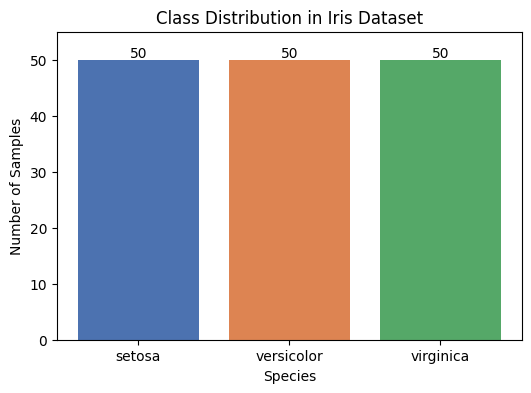

In [74]:
import matplotlib.pyplot as plt

counts = df['species'].value_counts().sort_index()  
print(counts)

class_names = iris.target_names

plt.figure(figsize=(6, 4))
plt.bar(class_names, counts.values, color=['#4C72B0', '#DD8452', '#55A868'])
plt.xlabel('Species')
plt.ylabel('Number of Samples')
plt.title('Class Distribution in Iris Dataset')
for i, v in enumerate(counts.values):
    plt.text(i, v + 0.5, str(v), ha='center')
plt.ylim(0, max(counts.values) + 5)
plt.show()

All the three target classes are equally distributed, hence no class imbalance

In [75]:
df.isna().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

No missing values

In [76]:
df.duplicated().sum()

np.int64(1)

In [77]:
df[df.duplicated(keep=False)]

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
101,5.8,2.7,5.1,1.9,2
142,5.8,2.7,5.1,1.9,2


Duplicate preserved as two flowers of the same species can be of same size and can be considered as a genuine data point

## **Task 2: Data Preparation** 

* Split the dataset into training (80%) and testing (20%) sets using random_state=42.
* Briefly explain why the dataset is divided into training and testing sets.


In [78]:
from sklearn.model_selection import train_test_split

X=df.drop('species',axis='columns')
y=df['species']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

Datasets are divided into train and test dataset so that the model is blind to one part of the dataset(test data) while "training" it using the train data.
The model learns on the train data and the model quality is evaluated using the new and unseen test data to accurately evaluate the model's performance.

## **Task 3: Building a Decision Tree Classifier**

* Train a Decision Tree classifier using the default parameters.
* Predict the class labels for the test dataset.
* Evaluate the model using:
    * Accuracy Score
    * Confusion Matrix
    * Classification Report


In [79]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)

In [80]:
y_pred

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0])

In [81]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred, target_names=iris.target_names))

Accuracy: 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## **Task 4: Visualizing the Decision Tree**
* Visualize the trained Decision Tree using plot_tree().
* From the visualization, identify:
    * Root node
    * Internal nodes
    * Leaf nodes
    * Maximum depth of the tree

Which feature is selected for the first split? Explain why you think this feature was chosen.


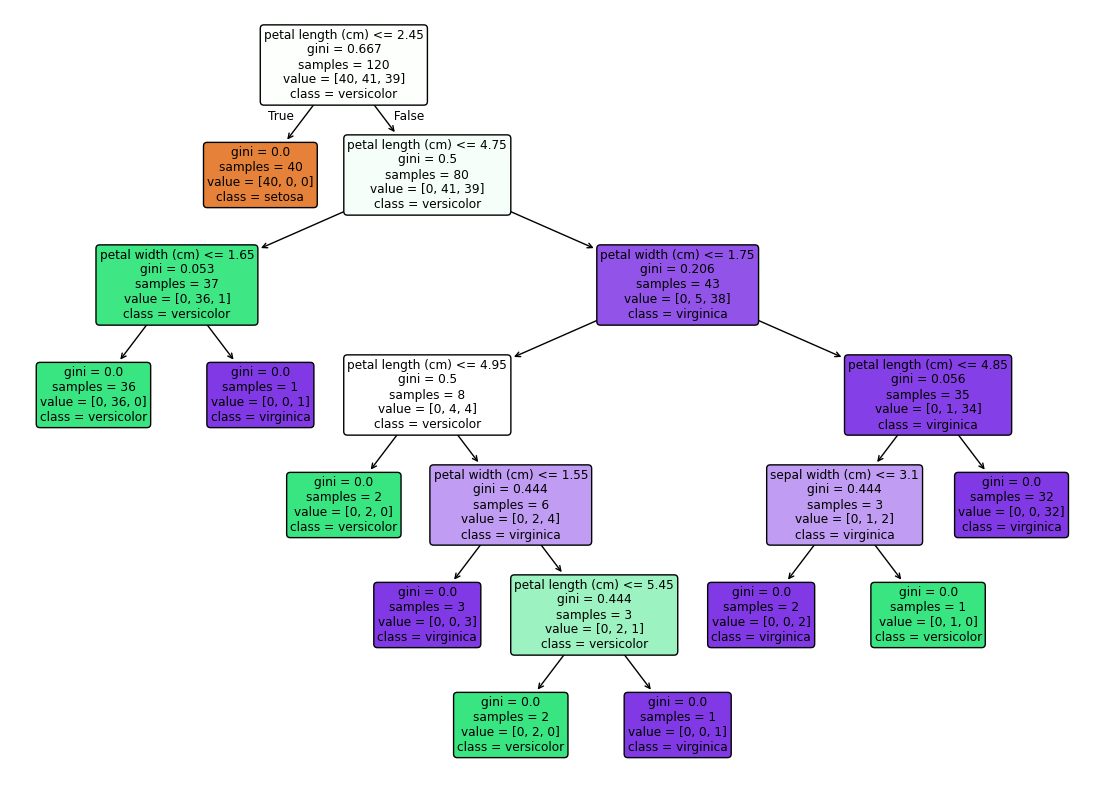

Max depth: 6
Number of leaves: 10
Root feature index: 2 = petal length (cm)


In [82]:
plt.figure(figsize=(14, 10))
plot_tree(dt, feature_names=iris.feature_names, class_names=iris.target_names,
          filled=True, rounded=True)
plt.show()

print("Max depth:", dt.get_depth())
print("Number of leaves:", dt.get_n_leaves())
print("Root feature index:", dt.tree_.feature[0], "=", iris.feature_names[dt.tree_.feature[0]])

Root Node: petal_length <= 2.45

Internal nodes: petal_length<=4.75, petal_width<=1.65, petal_length<=4.95, petal_width<=1.55, petal_length<=5.45, petal_width<=1.75, petal_length<=4.85, sepal_width<=3.1

Leaf nodes: setosa, versicolor, virginica

Maximum depth: 6

## **Task 5: Comparing Gini Index and Entropy**

Train two Decision Tree models using the following criteria:
* criterion='gini'
* criterion='entropy'


Compare the models based on:
* Accuracy
* Tree depth
* Number of leaf nodes
* Root feature selected
* Which criterion produces a simpler tree?

Summarize your observations in a table.


In [83]:
dt_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
dt_gini.fit(X_train, y_train)

dt_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt_entropy.fit(X_train, y_train)


,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


Gini: default in sklearn, faster to compute (no log), good general-purpose choice, tends to isolate the most frequent class into its own branch quickly.

Entropy: theoretically more "information-driven" (based on information gain from information theory), sometimes builds slightly more balanced trees, but computationally a bit heavier due to log calculations.

In practice: they usually produce very similar trees and near-identical accuracy. Gini is the common default for speed; entropy is preferred when you specifically care about information gain interpretability (e.g. ID3/C4.5 lineage).

In [84]:
for name, model in [("Gini", dt_gini), ("Entropy", dt_entropy)]:
    pred = model.predict(X_test)
    print(f"--- {name} ---")
    print("Accuracy:", accuracy_score(y_test, pred))
    print("Depth:", model.get_depth())
    print("Leaves:", model.get_n_leaves())
    print("Root feature:", iris.feature_names[model.tree_.feature[0]])

--- Gini ---
Accuracy: 1.0
Depth: 6
Leaves: 10
Root feature: petal length (cm)
--- Entropy ---
Accuracy: 1.0
Depth: 6
Leaves: 10
Root feature: petal length (cm)


Both criteria produce identical results on this dataset. Neither criterion produces a simpler tree since the structures are the same size.

Gini and Entropy are both impurity measures that tend to agree strongly on which splits are best. The small numerical differences between the two formulas rarely change which feature/threshold wins at each node, so the resulting trees often end up structurally identical

## **Task 6: Effect of Maximum Tree Depth**

Train Decision Tree models using the following values of max_depth: 1,2,3,4,None


Answer the following:
* Which model is underfitting?
* Which model gives the best generalization?
* Which model is likely to overfit? 

Justify your answer.


In [86]:
depths = [1, 2, 3, 4, None]
for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    print(f"max_depth={d} | train_acc={train_acc:.3f} | test_acc={test_acc:.3f} | actual_depth={model.get_depth()}")

max_depth=1 | train_acc=0.675 | test_acc=0.633 | actual_depth=1
max_depth=2 | train_acc=0.950 | test_acc=0.967 | actual_depth=2
max_depth=3 | train_acc=0.958 | test_acc=1.000 | actual_depth=3
max_depth=4 | train_acc=0.975 | test_acc=1.000 | actual_depth=4
max_depth=None | train_acc=1.000 | test_acc=1.000 | actual_depth=6


* Which model is underfitting?
    
    Model is underfitted when max_depth = 1. The train and test accuracies are both unsatisfactory as the model doesn't learn enough about the dataset as the split is too simple.

* Which model gives the best generalization?

    When max_depth=3 the model is well generalised as train (0.958) and test (1.000) accuracy are both high and close together, achieving perfect test performance without needing excessive complexity (only depth 3, not 6).

* Which model is likely to overfit? 

    When max_depth=None, the model is overfitted as both the train and test accuracies are perfect 1. The model just memorises the dataset and cannot generalise on a different dataset



## **Task 7: Effect of min_samples_split**

Train Decision Tree models using:2,5,10,20

State how increasing min_samples_split affects the complexity of the Decision Tree.


In [88]:
for mss in [2, 5, 10, 20]:
    model = DecisionTreeClassifier(min_samples_split=mss, random_state=42)
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    print(f"min_samples_split={mss} | acc={acc:.3f} | depth={model.get_depth()} | leaves={model.get_n_leaves()}")

min_samples_split=2 | acc=1.000 | depth=6 | leaves=10
min_samples_split=5 | acc=1.000 | depth=5 | leaves=8
min_samples_split=10 | acc=1.000 | depth=4 | leaves=6
min_samples_split=20 | acc=1.000 | depth=4 | leaves=6



| min_samples_split | Accuracy | Depth | Leaves | Observation |
|---|---|---|---|---|
| 2  | 1.000 | 6 | 10 | Default — most complex tree, splits allowed even with very few samples |
| 5  | 1.000 | 5 | 8  | Slightly simpler, accuracy unaffected |
| 10 | 1.000 | 4 | 6  | Simpler still, accuracy holds perfectly |
| 20 | 1.000 | 4 | 6  | Same as 10 — no further simplification, accuracy still perfect |

Observation: Increasing min_samples_split steadily reduces tree depth and leaf count (complexity goes down) without hurting accuracy at all on this dataset. It plateaus at depth=4/leaves=6 beyond min_samples_split=10, meaning Iris doesn't need more splitting than that to be perfectly classified — the extra splits in the default tree (depth=6) were unnecessary complexity.


## **Task 8: Effect of min_samples_leaf**

Train Decision Tree models using:
1
2
5
10

Explain how changing min_samples_leaf influences overfitting.


In [89]:
for msl in [1, 2, 5, 10]:
    model = DecisionTreeClassifier(min_samples_leaf=msl, random_state=42)
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    print(f"min_samples_leaf={msl} | acc={acc:.3f} | depth={model.get_depth()} | leaves={model.get_n_leaves()}")

min_samples_leaf=1 | acc=1.000 | depth=6 | leaves=10
min_samples_leaf=2 | acc=1.000 | depth=5 | leaves=8
min_samples_leaf=5 | acc=1.000 | depth=4 | leaves=6
min_samples_leaf=10 | acc=0.967 | depth=4 | leaves=6


| min_samples_leaf | Accuracy | Depth | Leaves | Observation |
|---|---|---|---|---|
| 1  | 1.000 | 6 | 10 | Default — leaves can be as small as 1 sample, most complex |
| 2  | 1.000 | 5 | 8  | Simpler tree, accuracy unaffected |
| 5  | 1.000 | 4 | 6  | Simpler still, accuracy still perfect |
| 10 | 0.967 | 4 | 6  | Accuracy drops — leaf size restriction now too strict, forcing the tree to merge samples that actually belonged to different classes |

Observation: min_samples_leaf behaves similarly at first (simplifying the tree with no accuracy cost), but unlike min_samples_split, pushing it too far (10) starts to hurt accuracy. This shows min_samples_leaf directly controls overfitting vs underfitting — small values overfit to individual points, but overly large values underfit by forcing leaves to contain samples from more than one true class.

## **Task 9**

1. criterion parameter: Decides how the tree measures impurity (Gini or Entropy) to pick the best feature/threshold at each split.

2. max_depth: Too small (e.g. 1) causes underfitting — tree can't capture patterns. Too large/unlimited causes overfitting — tree memorizes training data. A moderate depth (3) balances both.

3. min_samples_split / min_samples_leaf: Larger values stop the tree from creating splits or leaves based on just a handful of samples, forcing fewer, more general splits — this directly reduces tree depth and leaf count.

4. Greatest impact: max_depth had the biggest impact — accuracy jumped from 0.633 (test) at depth=1 to 1.000 at depth=3, the largest swing of any hyperparameter tested. min_samples_split/leaf only fine-tuned complexity without changing accuracy much (until min_samples_leaf=10, which dropped accuracy to 0.967).

5. Recommendation: max_depth=3 with default min_samples_split/min_samples_leaf. It reaches perfect test accuracy (1.000) with train accuracy close behind (0.958), using the simplest possible tree — no extra depth or leaves needed, avoiding the unnecessary complexity of the unrestricted default tree (depth=6).